<a href="https://colab.research.google.com/github/niruinso/Course_Work/blob/develop/src/Ensembles.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')
np.random.seed(42)

## Давайте чуть углубимся и рассмотрим ансамбли моделей. Ансамбли отличаются тем, что они используют несколько обычных моделей и на основе их результатов делают предсказания. Рассмотрим несколько таких моделей

## Начнем с VotingRegressor (регрессор с голосованием): он просто обучает несколько моделей и находит предсказание как комбинацию прогнозов всех моделей. Можно передать моделям веса, или просто считать, что веса у моделей одинаковы, тогда результатом будет среднее всех предсказаний. Давайте представим несложную реализацию этого ансамбля

In [ ]:
class MyVotingRegressor:
    def __init__(self, estimators, weights=None):
        self.estimators = estimators
        self.weights = weights

        if weights is not None:
            if len(weights) != len(estimators):
                raise ValueError("Number of weights must match number of estimators")
            if abs(sum(weights) - 1.0) > 1e-10:
                self.weights = np.array(weights) / sum(weights)
            else:
                self.weights = np.array(weights)

    def fit(self, X, y):
        for est in self.estimators:
            est.fit(X, y)
        return self

    def predict(self, X):
        if self.weights is None:
            weights = np.full(len(self.estimators), 1/len(self.estimators))
        else:
            weights = self.weights

        predictions = []
        for est in self.estimators:
            pred = est.predict(X)
            predictions.append(pred)

        est_predictions = pd.DataFrame(predictions).T

        return est_predictions.dot(weights)

## Для проверки кореектности и сравнения с библиотечной версией модели воспользуемся набором данных california_housing - цены на дома в Калифорнии

In [ ]:
from sklearn.datasets import fetch_california_housing

housing = fetch_california_housing(as_frame=True)
X, y = housing.data, housing.target

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train = pd.DataFrame(scaler.fit_transform(X_train), columns=scaler.get_feature_names_out())
X_test = pd.DataFrame(scaler.transform(X_test), columns=scaler.get_feature_names_out())

In [ ]:
from sklearn.svm import SVR
from sklearn.linear_model import SGDRegressor
from sklearn.tree import DecisionTreeRegressor

estimators = [SVR(), SGDRegressor(), DecisionTreeRegressor()]

myVoting = MyVotingRegressor(estimators)
myVoting.fit(X_train, y_train)

In [ ]:
from sklearn.metrics import root_mean_squared_error as rmse, mean_absolute_error as mae, r2_score as r2

y_pred = myVoting.predict(X_test)
print(f"RMSE: {rmse(y_pred, y_test)}, MAE: {mae(y_pred, y_test)}, R2-score: {r2(y_test, y_pred)}")

RMSE: 0.5879836707832682, MAE: 0.4009391673496516, R2-score: 0.7361703080118777


## А теперь давайте посмотрим на предсказание только на одной модели

In [ ]:
svr_model = SVR()
svr_model.fit(X_train, y_train)
y_pred_svr = svr_model.predict(X_test)
print(f"RMSE: {rmse(y_pred_svr, y_test)}, MAE: {mae(y_pred_svr, y_test)}, R2-score: {r2(y_test, y_pred_svr)}")

RMSE: 0.5974981438748281, MAE: 0.398599076952054, R2-score: 0.7275628923016775


In [ ]:
sgd_reg_model = SGDRegressor()
sgd_reg_model.fit(X_train, y_train)
y_pred_sgd_reg_model = sgd_reg_model.predict(X_test)
print(f"RMSE: {rmse(y_pred_sgd_reg_model, y_test)}, MAE: {mae(y_pred_sgd_reg_model, y_test)}, R2-score: {r2(y_test, y_pred_sgd_reg_model)}")

RMSE: 0.8335386506561594, MAE: 0.6087545574387934, R2-score: 0.46979401570464174


In [ ]:
tree_model = DecisionTreeRegressor()
tree_model.fit(X_train, y_train)
y_pred_tree = tree_model.predict(X_test)
print(f"RMSE: {rmse(y_pred_tree, y_test)}, MAE: {mae(y_pred_tree, y_test)}, R2-score: {r2(y_test, y_pred_tree)}")

RMSE: 0.7112550566292266, MAE: 0.45710045784883724, R2-score: 0.6139497180035003


## Вообще говоря, виден прогресс в предсказаниях

## Сравним с версией из библиотеки sklearn

In [ ]:
from sklearn.ensemble import VotingRegressor

estimators = [
    ('svr', SVR()),
    ('sgd', SGDRegressor(random_state=42, max_iter=1000)),
    ('dt', DecisionTreeRegressor(random_state=42))
]

sklearnVoting = VotingRegressor(estimators)
sklearnVoting.fit(X_train, y_train)

VotingRegressor(estimators=[('svr', SVR()),
                            ('sgd', SGDRegressor(random_state=42)),
                            ('dt', DecisionTreeRegressor(random_state=42))])

In [ ]:
def show_comparison(my_model, sklearn_model, types_of_comparing):
    print(types_of_comparing)
    my_model_prediction = my_model.predict(X_test)
    sklearn_model_prediction = sklearn_model.predict(X_test)
    print(f"MAE: My Model: {mae(y_test, my_model_prediction)} vs Sklearn: {mae(y_test, sklearn_model_prediction)}")
    print(f"RMSE: My Model: {rmse(y_test, my_model_prediction)} vs Sklearn: {rmse(y_test, sklearn_model_prediction)}")
    print(f"R-Squared: My Model: {r2(y_test, my_model_prediction)} vs Sklearn: {r2(y_test, sklearn_model_prediction)}")

In [ ]:
show_comparison(myVoting, sklearnVoting, "VotingRegressor")

VotingRegressor
MAE: My Model: 0.4009391673496516 vs Sklearn: 0.3960064580962062
RMSE: My Model: 0.5879836707832682 vs Sklearn: 0.5834707039431136
R-Squared: My Model: 0.7361703080118777 vs Sklearn: 0.740204723858899


## Давайте посмотрим на графике отклонение от предсказаний

In [ ]:
def vizual_pred_test(y_test, y_pred, title):
    plt.figure(figsize=(10, 10))

    plt.scatter(y_test, y_pred, alpha=0.3, s=10, c='blue', label='Предсказания')

    min_val = min(y_test.min(), y_pred.min())
    max_val = max(y_test.max(), y_pred.max())
    plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Идеальное предсказание')

    plt.xlabel('Тестовые данные', fontsize=12)
    plt.ylabel('Предсказанные точки', fontsize=12)
    plt.title(title, fontsize=14)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.axis('equal')

    plt.tight_layout()
    plt.show()

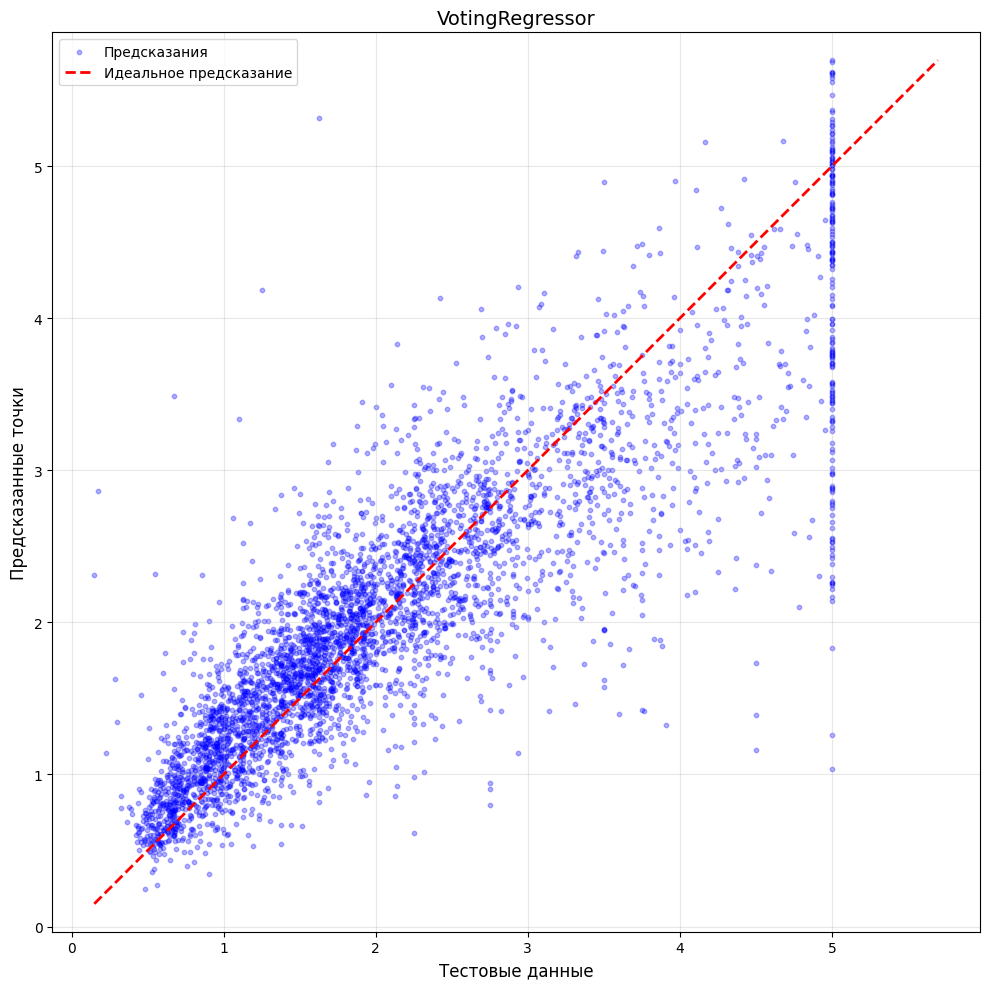

In [ ]:
vizual_pred_test(y_test, y_pred, 'VotingRegressor')

## Можем даже посмотреть на предсказания на графике: сначала по отдельности каждой модели, и какое решение принял голосователь

In [ ]:
xt = X_test[:20]

pred1 = svr_model.predict(xt)
pred2 = sgd_reg_model.predict(xt)
pred3 = tree_model.predict(xt)
pred4 = myVoting.predict(xt)

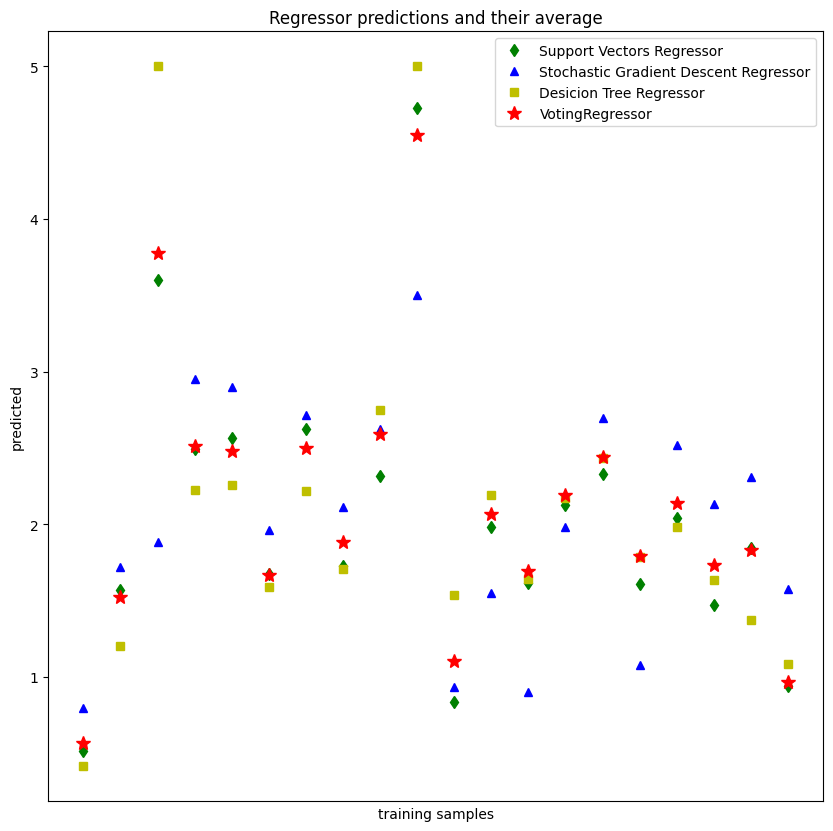

In [ ]:
plt.figure(figsize=(10, 10))
plt.plot(pred1, "gd", label="Support Vectors Regressor")
plt.plot(pred2, "b^", label="Stochastic Gradient Descent Regressor")
plt.plot(pred3, "ys", label="Desicion Tree Regressor")
plt.plot(pred4, "r*", ms=10, label="VotingRegressor")

plt.tick_params(axis="x", which="both", bottom=False, top=False, labelbottom=False)
plt.ylabel("predicted")
plt.xlabel("training samples")
plt.legend(loc="best")
plt.title("Regressor predictions and their average")

plt.show()

## BaggingRegressor (бэггинг): берется какая-то модель, создают много ее копий и обучают на разных подвыборках обучающей выборки. Выделяют бэггинг и вставку: в первом случае подвыборка берется с заменой, а в другом - без замены. Данный выбор регулируется при помощи параметра bootstrap.

In [ ]:
from sklearn.base import clone

class MyBaggingRegressor():
    def __init__(self, estimator=None, n_estimators=10, bootstrap=True):
        self.estimator = estimator
        self.n_estimators = n_estimators
        self.bootstrap = bootstrap
        self.estimators = []

    def fit(self, X, y):
        if hasattr(X, 'values'):
            X = X.values
        if hasattr(y, 'values'):
            y = y.values
        self.estimators = []
        n_samples = X.shape[0]

        for _ in range(self.n_estimators):
            est = clone(self.estimator)

            if self.bootstrap:
                indices = np.random.choice(n_samples, n_samples, replace=True)
                X_bootstrap = X[indices]
                y_bootstrap = y[indices]
            else:
                indices = np.random.choice(n_samples, n_samples, replace=False)
                X_bootstrap = X
                y_bootstrap = y

            est.fit(X_bootstrap, y_bootstrap)
            self.estimators.append(est)

        return self

    def predict(self, X):
        predictions = np.column_stack([est.predict(X) for est in self.estimators])

        return np.mean(predictions, axis=1)

In [ ]:
base_estimator = DecisionTreeRegressor(max_depth=5)

myBaggingRegressor = MyBaggingRegressor(estimator=base_estimator)
myBaggingRegressor.fit(X_train, y_train)

In [ ]:
y_pred = myBaggingRegressor.predict(X_test)
print(f"RMSE: {rmse(y_pred, y_test)}, MAE: {mae(y_pred, y_test)}, R2-score: {r2(y_test, y_pred)}")

RMSE: 0.6879486905926631, MAE: 0.49742857270696794, R2-score: 0.6388353493094312


## Опять же сравним с библиотечной версией

In [ ]:
from sklearn.ensemble import BaggingRegressor

sklearnBaggingRegressor = BaggingRegressor(estimator=base_estimator)
sklearnBaggingRegressor.fit(X_train, y_train)

BaggingRegressor(estimator=DecisionTreeRegressor(max_depth=5))

In [ ]:
show_comparison(myBaggingRegressor, sklearnBaggingRegressor, "BaggingRegressor")

BaggingRegressor
MAE: My Model: 0.49742857270696794 vs Sklearn: 0.49641977526970665
RMSE: My Model: 0.6879486905926631 vs Sklearn: 0.6891102066294541
R-Squared: My Model: 0.6388353493094312 vs Sklearn: 0.637614756334804


In [ ]:
tree_model = DecisionTreeRegressor(max_depth=5)
tree_model.fit(X_train, y_train)
y_pred_tree = tree_model.predict(X_test)
print(f"RMSE: {rmse(y_pred_tree, y_test)}, MAE: {mae(y_pred_tree, y_test)}, R2-score: {r2(y_test, y_pred_tree)}")

RMSE: 0.7242338143386247, MAE: 0.5222592972077787, R2-score: 0.5997321244428706


## Прогресс на лицо

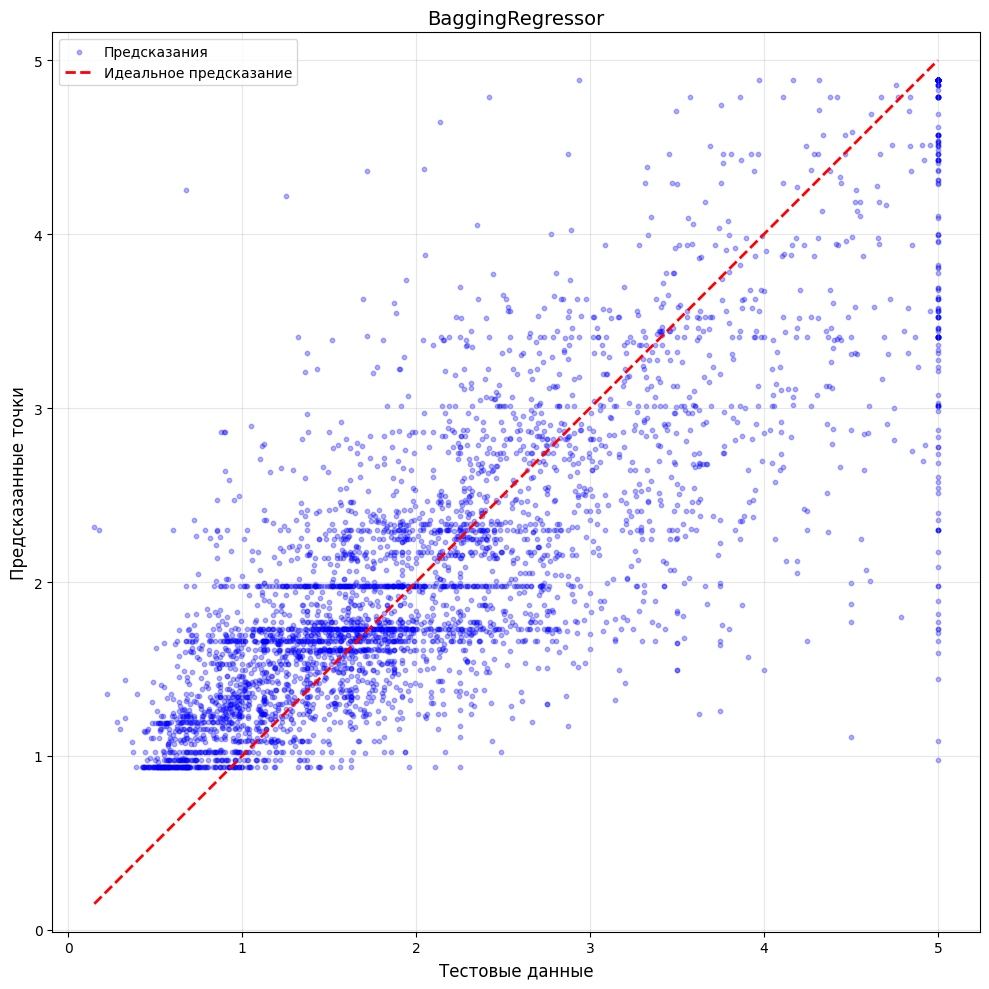

In [ ]:
vizual_pred_test(y_test, y_pred, 'BaggingRegressor')

## Попробуем увеличить количество деревьев

In [ ]:
myBaggingRegressor = MyBaggingRegressor(estimator=base_estimator, n_estimators=50)
myBaggingRegressor.fit(X_train, y_train)
y_pred = myBaggingRegressor.predict(X_test)
print(f"RMSE: {rmse(y_pred, y_test)}, MAE: {mae(y_pred, y_test)}, R2-score: {r2(y_test, y_pred)}")

RMSE: 0.6804919530355732, MAE: 0.49050946684040203, R2-score: 0.6466223096488581


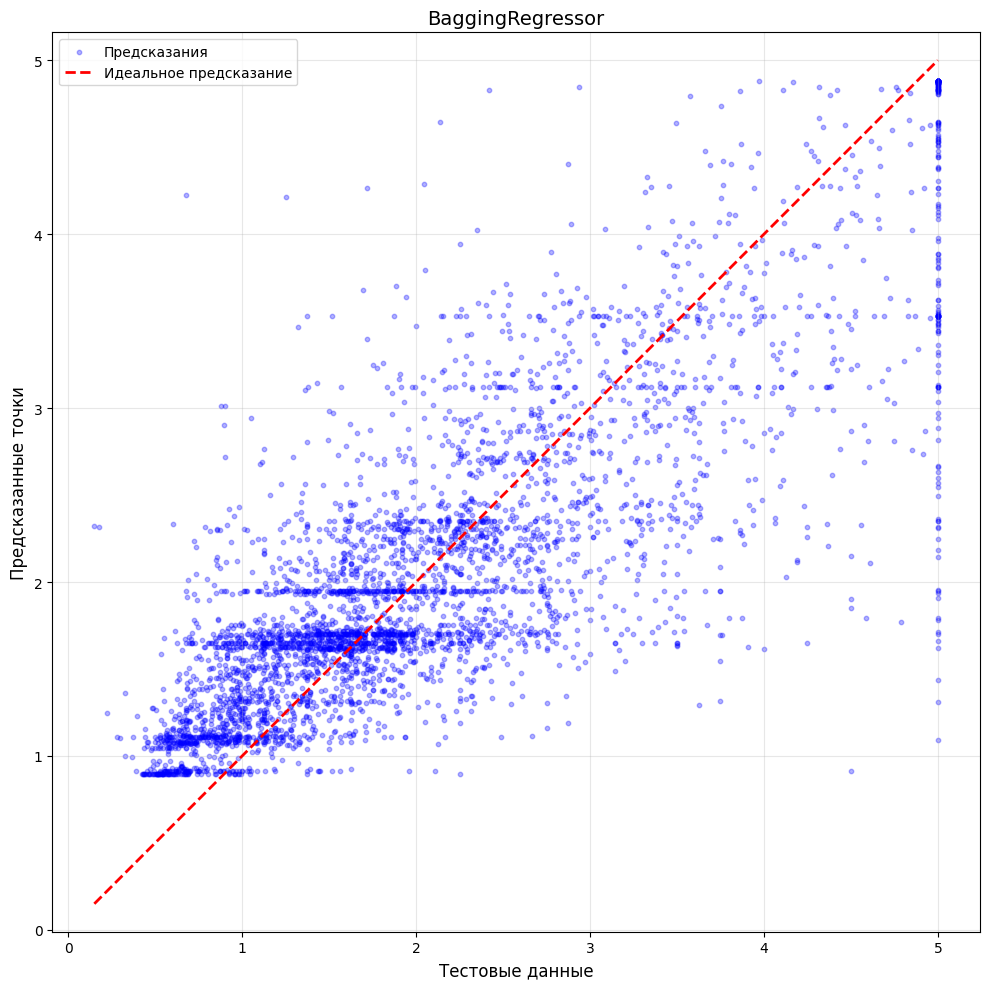

In [ ]:
vizual_pred_test(y_test, y_pred, 'BaggingRegressor')

## А теперь поставим bootstrap=False

In [ ]:
myBaggingRegressor = MyBaggingRegressor(estimator=base_estimator, bootstrap=False)
myBaggingRegressor.fit(X_train, y_train)
y_pred = myBaggingRegressor.predict(X_test)
print(f"RMSE: {rmse(y_pred, y_test)}, MAE: {mae(y_pred, y_test)}, R2-score: {r2(y_test, y_pred)}")

RMSE: 0.7242338143386247, MAE: 0.5222592972077787, R2-score: 0.5997321244428706


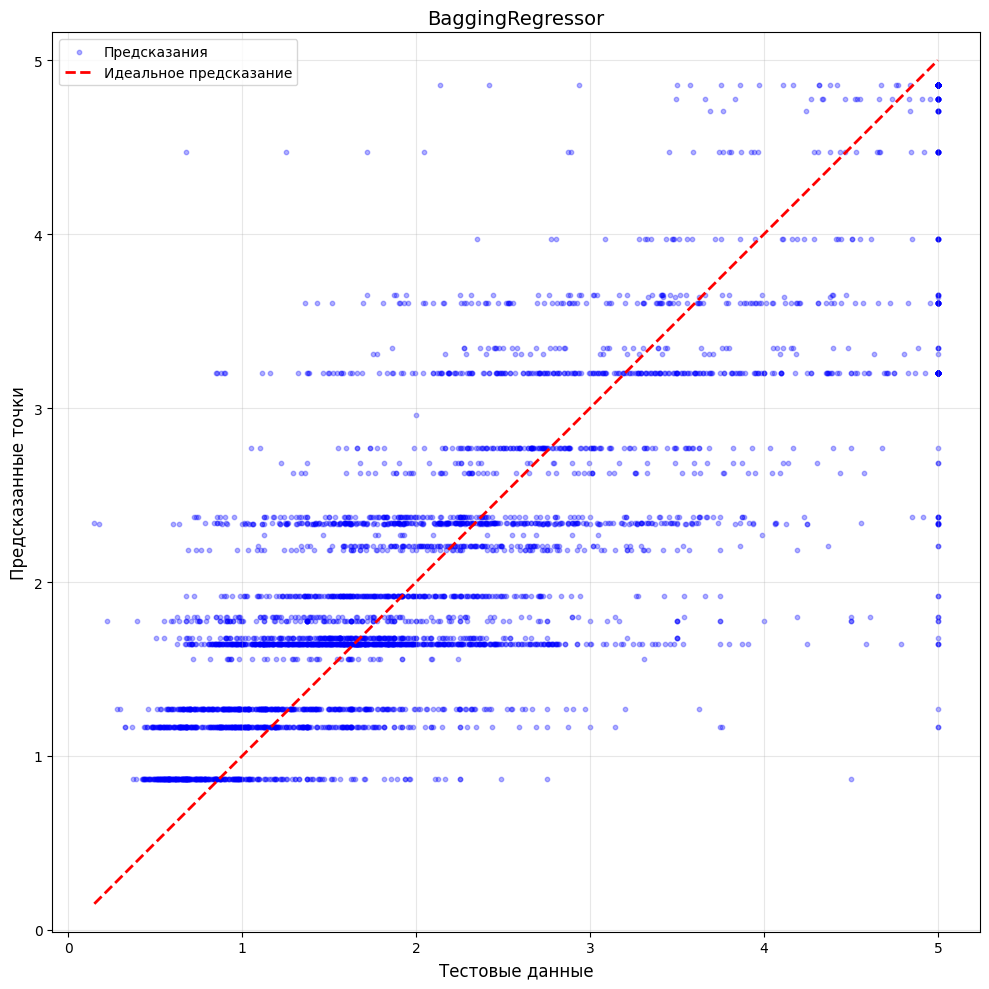

In [ ]:
vizual_pred_test(y_test, y_pred, 'BaggingRegressor')

## RandomForestRegressor (Случайный Лес): обучается много деревьев принятия решений (на основе какого-то подпространства всей обучающей выборки - одно дерево получает определенные объекты и его признаки)

In [ ]:
class MyRandomForest:
    def __init__(self, n_estimators=100, max_depth=None,
                 max_features=1.0, n_jobs=-1, random_state=42):
        self.n_estimators = n_estimators
        self.max_depth = max_depth
        self.max_features = max_features
        self.n_jobs = n_jobs
        self.random_state = random_state
        self.trained_trees_info = []
        self.general_random = np.random.RandomState(self.random_state)

    def _rsm_bootstrapping(self, X, y):
        n_samples, n_features = X.shape
        max_features = self.max_features * n_features

        sample_indexes = self.general_random.choice(n_samples, n_samples)
        features = self.general_random.choice(X.columns, round(max_features))
        X_b, y_b = X.iloc[sample_indexes][features], y.iloc[sample_indexes]

        return X_b, y_b

    def _train_tree(self, X, y):
          tree = DecisionTreeRegressor(max_depth=self.max_depth,
                                         random_state=self.random_state)

          return tree.fit(X, y), X.columns

    def fit(self, X, y):
        for _ in range(self.n_estimators):
            X_b, y_b = self._rsm_bootstrapping(X, y)

            tree, features = self._train_tree(X_b, y_b)

            self.trained_trees_info.append((tree, features))

    def predict(self, samples):
        predictions = []

        for tree_i, tree_i_features in self.trained_trees_info:
            tree_pred = tree_i.predict(samples[tree_i_features])
            predictions.append(tree_pred)

        trees_predictions = pd.DataFrame(predictions)

        return np.array(trees_predictions.mean(axis=0))

In [ ]:
myRandomForest = MyRandomForest()
myRandomForest.fit(X_train, y_train)

In [ ]:
y_pred = myRandomForest.predict(X_test)
print(f"RMSE: {rmse(y_pred, y_test)}, MAE: {mae(y_pred, y_test)}, R2-score: {r2(y_test, y_pred)}")

RMSE: 0.5150564454517255, MAE: 0.3572139447674418, R2-score: 0.7975569868595651


## Библиотечная версия

In [ ]:
from sklearn.ensemble import RandomForestRegressor

SklearnRandomForest = RandomForestRegressor()
SklearnRandomForest.fit(X_train, y_train)

RandomForestRegressor()

In [ ]:
show_comparison(myRandomForest, SklearnRandomForest, "RandomForestRegressor")

RandomForestRegressor
MAE: My Model: 0.3572139447674418 vs Sklearn: 0.3273584800872094
RMSE: My Model: 0.5150564454517255 vs Sklearn: 0.5034481950980967
R-Squared: My Model: 0.7975569868595651 vs Sklearn: 0.8065794043262909


## RandomForest - очень сильный инструмент в предсказаниях. Однако, в отличие от одного дерева, у случайного леса есть один недостаток - нельзя точно сказать, какие паттерны он нашел.

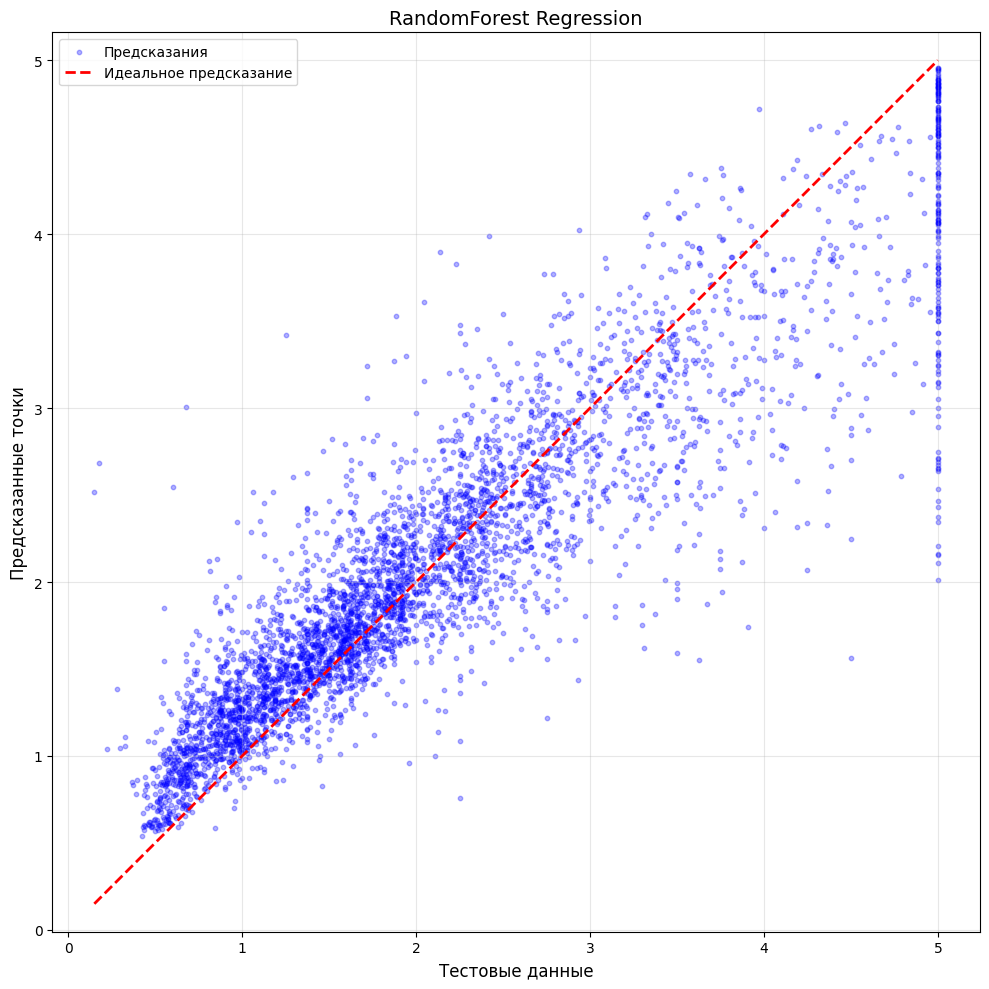

In [ ]:
vizual_pred_test(y_test, y_pred, 'RandomForest Regression')

## Boosting - обучение на основе нескольких слабых учеников, на каждом шаге новая модель пытается исправить ошибки предыдущей модели. Ниже приведу пример бустинга на основе градиентного метода, который обучает деревья принятия решений на основе ошибки прогноза предыдущей модели. То есть на каждом шаге мы находим, как сильно ошиблась предыдущая модель, и нашим целевым признаком будет величина этой ошибки

In [ ]:
class SquaredErrorLoss():
    def __init__(self):
        pass

    def loss(self, y, preds):
        return np.mean((y - preds) ** 2)

    def negative_gradient(self, y, preds):
        return y - preds

class GradientBoostingMachine():
    def __init__(self, n_trees=100, learning_rate=0.1, max_depth=1):
        self.n_trees = n_trees
        self.learning_rate = learning_rate
        self.max_depth = max_depth

    def fit(self, X, y):
        objective = SquaredErrorLoss()

        self.trees = []

        self.base_prediction = np.mean(y)

        current_predictions = self.base_prediction * np.ones(shape=y.shape)

        for _ in range(self.n_trees):
            residuals = objective.negative_gradient(y, current_predictions)

            tree = DecisionTreeRegressor(max_depth=self.max_depth)
            tree.fit(X, residuals)

            self.trees.append(tree)

            current_predictions += self.learning_rate * tree.predict(X)

    def predict(self, X):
        predictions = self.base_prediction * np.ones(X.shape[0])

        for tree in self.trees:
            predictions += self.learning_rate * tree.predict(X)

        return predictions

In [ ]:
myBoostingRegressor = GradientBoostingMachine()
myBoostingRegressor.fit(X_train, y_train)

In [ ]:
y_pred = myRandomForest.predict(X_test)
print(f"RMSE: {rmse(y_pred, y_test)}, MAE: {mae(y_pred, y_test)}, R2-score: {r2(y_test, y_pred)}")

RMSE: 0.5150564454517255, MAE: 0.3572139447674418, R2-score: 0.7975569868595651


## Хороший результат, и это при всем том, что все деревья имели глубину 1

## Не забываем сравнить с версией из sklearn

In [ ]:
from sklearn.ensemble import GradientBoostingRegressor

SklearnBoostingRegressor = GradientBoostingRegressor(max_depth=1)
SklearnBoostingRegressor.fit(X_train, y_train)

GradientBoostingRegressor(max_depth=1)

In [ ]:
show_comparison(myBoostingRegressor, SklearnBoostingRegressor, "BoostingRegressor")

BoostingRegressor
MAE: My Model: 0.5149101858487869 vs Sklearn: 0.5149101858487867
RMSE: My Model: 0.699479790191394 vs Sklearn: 0.6994797901913938
R-Squared: My Model: 0.6266265074412127 vs Sklearn: 0.626626507441213


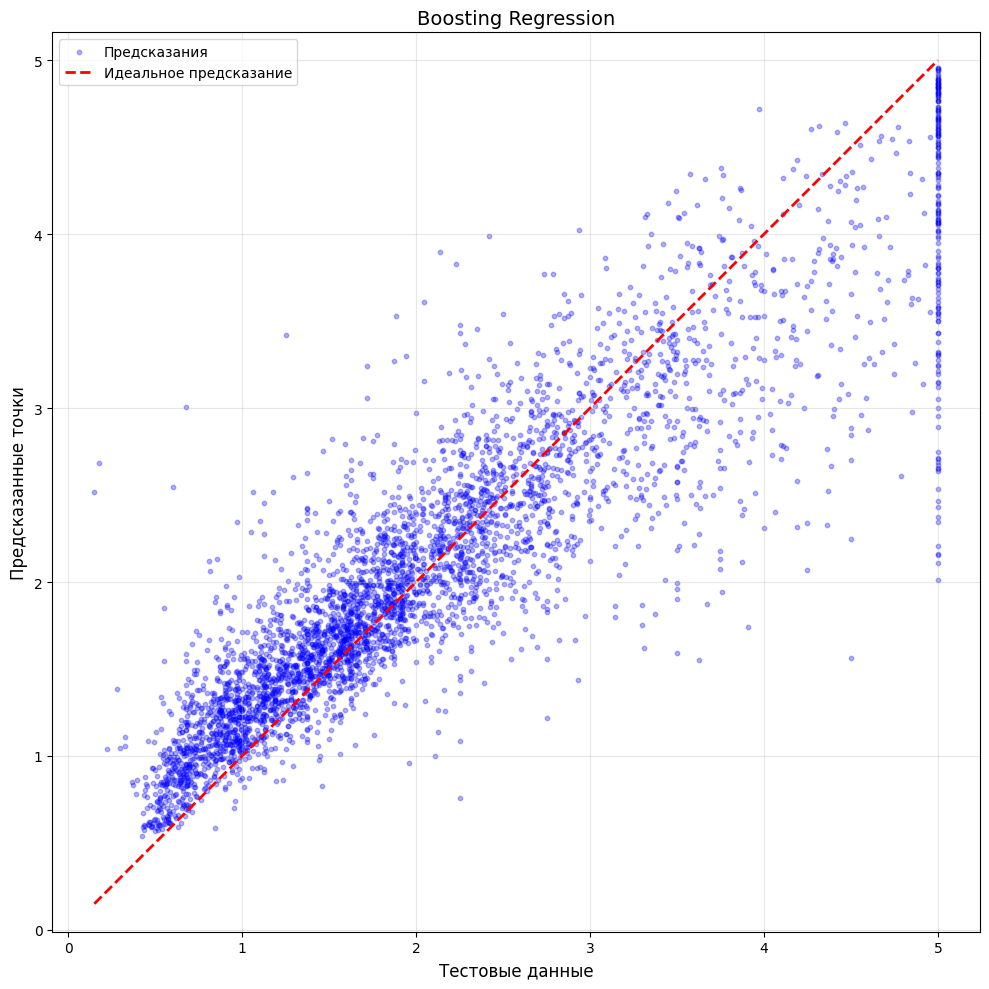

In [ ]:
vizual_pred_test(y_test, y_pred, 'Boosting Regression')

## Чуток увеличим глубину

In [ ]:
myBoostingRegressor = GradientBoostingMachine(max_depth=3)
myBoostingRegressor.fit(X_train, y_train)
y_pred = myBoostingRegressor.predict(X_test)
print(f"RMSE: {rmse(y_pred, y_test)}, MAE: {mae(y_pred, y_test)}, R2-score: {r2(y_test, y_pred)}")

RMSE: 0.5422167577867202, MAE: 0.37165044848436773, R2-score: 0.7756433164710084


## Мы улучшили наши деревья, но метрики ухудшились. Дело в том, что бустинг происходит для слабых учеников, поэтому нет смысла пытаться как-то сильно улучшать деревья. В этом и прелесть бустинга

## И последний ансамбль - стекинг. Стекинг (Stacked Generalization) - это метод ансамблирования, который объединяет несколько моделей (базовых алгоритмов) с помощью мета-модели, которая обучается на предсказаниях базовых моделей. В отличие от бэггинга и бустинга, где используется простая агрегация (усреднение, голосование), стекинг использует обучаемый алгоритм для комбинации предсказаний. Приведу простую реализацию

In [ ]:
from sklearn.model_selection import KFold, cross_val_predict

class MyStackingRegressor():
    def __init__(self, estimators, final_estimator=None, cv=None, passthrough=False):
        self.estimators = estimators
        self.final_estimator = final_estimator
        self.cv = cv
        self.passthrough = passthrough
        self.named_estimators_ = dict(estimators)
        self.estimators_ = []

    def fit(self, X, y):
        if hasattr(X, 'values'):
                X = X.values
        if hasattr(y, 'values'):
            y = y.values

        if self.final_estimator is None:
            self.final_estimator_ = SGDRegressor(random_state=42)
        else:
            self.final_estimator_ = clone(self.final_estimator)

        if self.cv is None:
            self.cv_ = 5
        else:
            self.cv_ = self.cv

        meta_features = self._fit_base_estimators(X, y)

        if self.passthrough:
            meta_features = np.hstack([meta_features, X])

        self.final_estimator_.fit(meta_features, y)

        return self

    def _fit_base_estimators(self, X, y):
        n_samples = X.shape[0]
        n_estimators = len(self.estimators)

        meta_features = np.zeros((n_samples, n_estimators))

        for i, (name, estimator) in enumerate(self.estimators):
            est = clone(estimator)

            if hasattr(self.cv_, '__iter__'):
                cv = self.cv_
            else:
                cv = KFold(n_splits=self.cv_)

            oof_predictions = cross_val_predict(
                est, X, y, cv=cv, method='predict', n_jobs=None
            )
            meta_features[:, i] = oof_predictions

            est.fit(X, y)
            self.estimators_.append((name, est))

        return meta_features

    def predict(self, X):
        meta_features = self._predict_base_estimators(X)

        if self.passthrough:
            meta_features = np.hstack([meta_features, X])

        return self.final_estimator_.predict(meta_features)

    def _predict_base_estimators(self, X):
        n_samples = X.shape[0]
        n_estimators = len(self.estimators)

        meta_features = np.zeros((n_samples, n_estimators))

        for i, (name, estimator) in enumerate(self.estimators_):
            meta_features[:, i] = estimator.predict(X)

        return meta_features

In [ ]:
estimators = [
    ('tree', DecisionTreeRegressor()),
    ('svm', SVR()),
    ('rf', RandomForestRegressor()),
]

myStacking = MyStackingRegressor(estimators)
myStacking.fit(X_train, y_train)

In [ ]:
y_pred = myStacking.predict(X_test)
print(f"RMSE: {rmse(y_pred, y_test)}, MAE: {mae(y_pred, y_test)}, R2-score: {r2(y_test, y_pred)}")

RMSE: 0.5042081472178699, MAE: 0.3317110572382257, R2-score: 0.8059950290769898


## И снова смотрим на результативность по сравнению с библиотечной моделью

In [ ]:
from sklearn.ensemble import StackingRegressor

SklearnStackingRegressor = StackingRegressor(estimators)
SklearnStackingRegressor.fit(X_train, y_train)

StackingRegressor(estimators=[('tree', DecisionTreeRegressor()), ('svm', SVR()),
                              ('rf', RandomForestRegressor())])

In [ ]:
show_comparison(myStacking, SklearnStackingRegressor, "StackingRegressor")

StackingRegressor
MAE: My Model: 0.3317110572382257 vs Sklearn: 0.32661437365089246
RMSE: My Model: 0.5042081472178699 vs Sklearn: 0.5021943772220744
R-Squared: My Model: 0.8059950290769898 vs Sklearn: 0.807541617387252


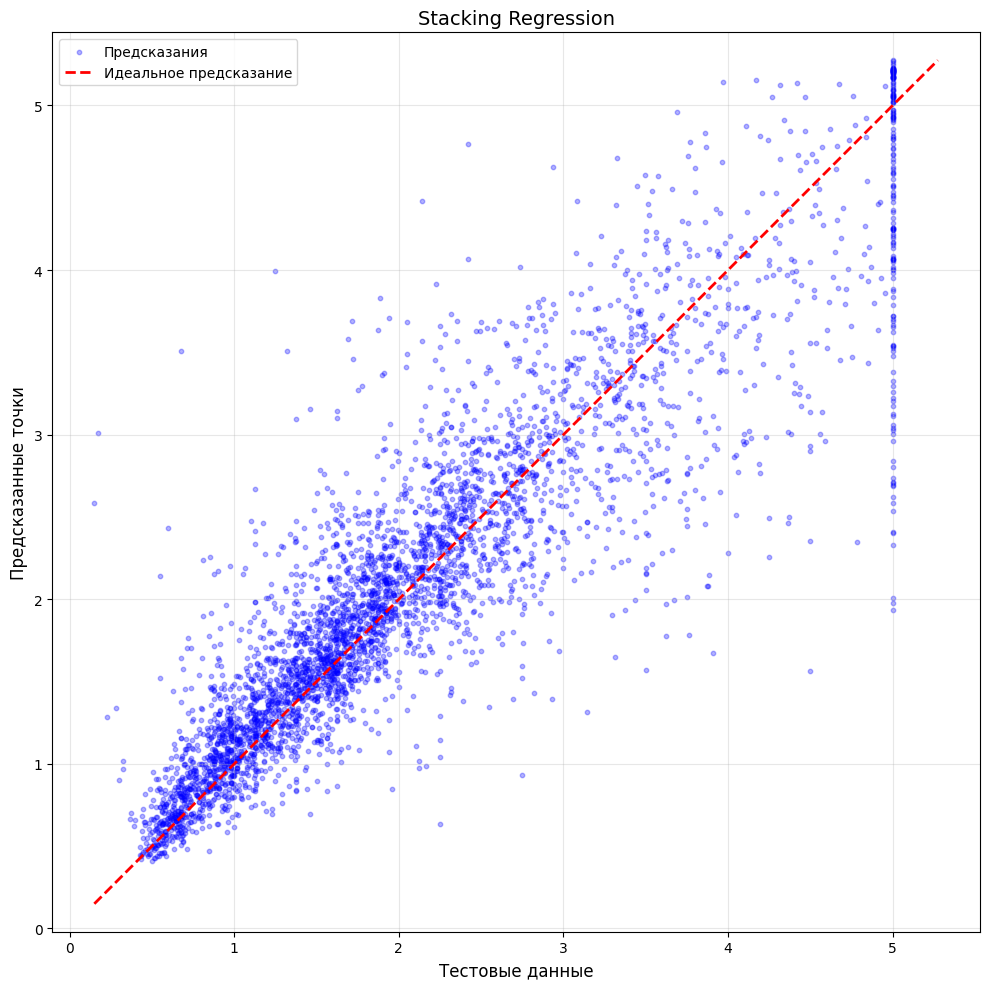

In [ ]:
vizual_pred_test(y_test, y_pred, 'Stacking Regression')

## Ну, напоследок попробуем чуток оптимизировать ансамбли

In [ ]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

In [ ]:
train_df = pd.read_csv("data/Train.csv")
valid_df = pd.read_csv("data/Valid.csv")

In [ ]:
X_train = train_df.drop('Exam_Score', axis=1)
X_valid = valid_df.drop('Exam_Score', axis=1)

y_train = train_df['Exam_Score']
y_valid= valid_df['Exam_Score']

## Мы успели до ансамблей обучить и оптимизировать несколько моделей. В файлах с результатами предсказаний мы сохранили и их гиперпарпаметры. Давайте воссоздадим несколько моделей и обучимся засчет выбора весов для VotingRegressor

In [ ]:
linear_res = pd.read_csv("data/result_linear.csv")
svm_res = pd.read_csv("data/results_svm.csv")
tree_knn_res = pd.read_csv("data/results_tree_knn.csv")

In [ ]:
linear_res

,Unnamed: 0,model,MAE,RMSE,R2
0,0,Poly Linear Regression,0.506658,2.269837,0.674013
1,1,Ridge,0.506636,2.269850,0.674010
2,2,Lasso,0.506741,2.269717,0.674048
3,3,ElasticNet,0.506713,2.269774,0.674032


In [ ]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import Ridge, Lasso

## Возьмем 4 модели (не вдаваться в суть, просто так захотелось)

In [ ]:
model1 = SVR(**eval(svm_res.iloc[0]['params']))
model2 = SVR(**eval(svm_res.iloc[2]['params']))
model4 = DecisionTreeRegressor(**eval(tree_knn_res.iloc[1]['params']))
model6 = Lasso()

estimators = [
    ("svr_rbf", model1),
    ("svr_sigmoid", model2),
    ("DecisionTree", model4),
    ("lasso", model6)
]

## Для VotingRegressor будем подбирать веса для наших моделей

In [ ]:
from itertools import product
from tqdm.notebook import tqdm

best_res = float('inf')
best_weights = [0, 0, 0, 0]
for weights in product(range(1, 4), repeat=len(best_weights)):
    weights = list(weights)

    VC = VotingRegressor(estimators, weights=weights)
    VC.fit(X_train, y_train)

    y_pred = VC.predict(X_valid)
    RMSE = rmse(y_pred, y_valid)

    if (best_res > RMSE):
        best_res = RMSE
        best_weights = weights

print(best_weights, sep='\n')

best_voting = VotingRegressor(estimators, weights=best_weights)

[3, 3, 1, 1]


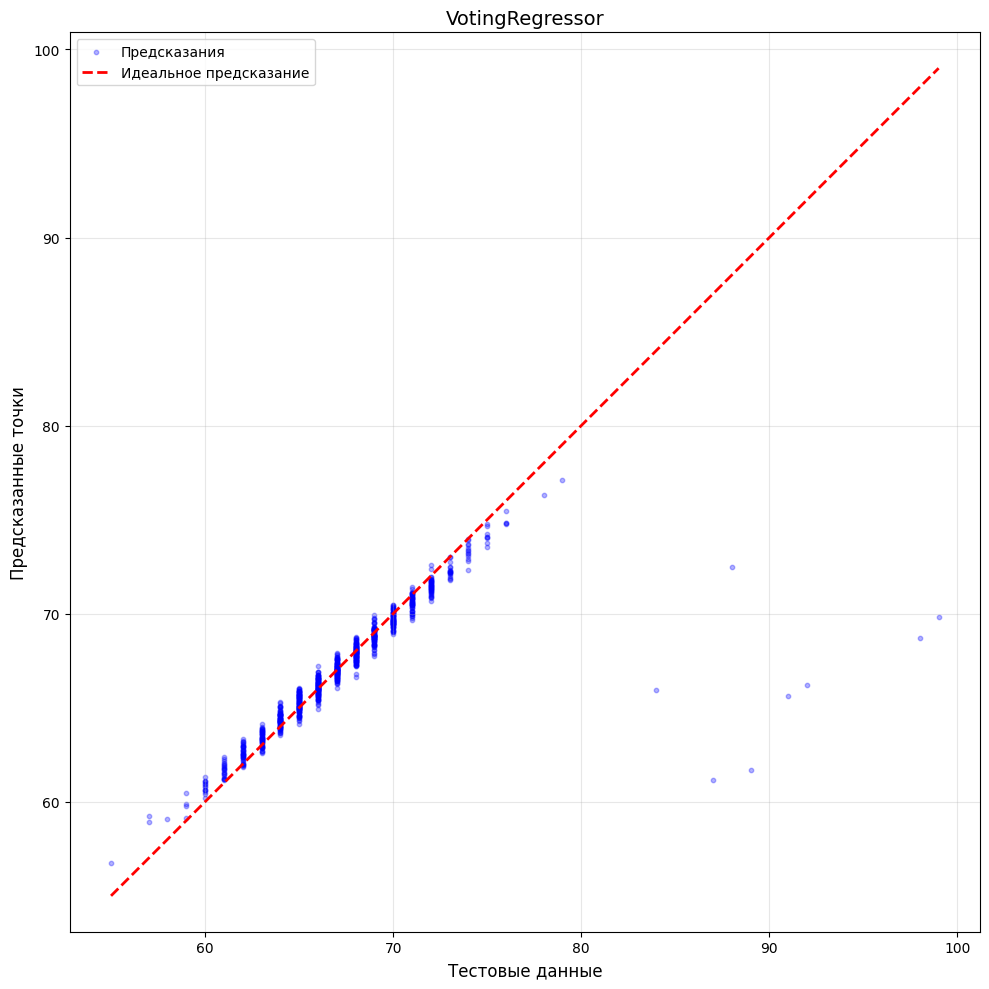

In [ ]:
best_voting.fit(X_train, y_train)
vizual_pred_test(y_valid, best_voting.predict(X_valid), 'VotingRegressor')

## Для BaggingRegressor будем экспериментировать с начальной моделью. Так как надо будет обучить слишком много, давайте вместо обычного GridSearch воспользуемся его случайно версией: разница лишь в том, что в случайной версии количество итераций ограничено и параметры выбираются случайно

In [ ]:
from scipy.stats import randint, uniform, loguniform
from sklearn.pipeline import Pipeline

n_iter = 50
base_configs = {
    'decision_tree': {
        'estimator': DecisionTreeRegressor(random_state=42),
        'param_dist': {
            'n_estimators': randint(20, 300),
            'max_samples': uniform(0.6, 0.4),
            'max_features': uniform(0.6, 0.4),
            'bootstrap': [True, False],
            'bootstrap_features': [True, False],
            'estimator__max_depth': randint(3, 30),
            'estimator__min_samples_split': randint(2, 20),
            'estimator__min_samples_leaf': randint(1, 10),
            'estimator__max_features': ['sqrt', 'log2', None],
        }
    },

    'svr': {
        'estimator': SVR(),
        'param_dist': {
            'n_estimators': randint(10, 100),
            'max_samples': uniform(0.7, 0.3),
            'max_features': uniform(0.7, 0.3),
            'bootstrap': [True, False],
            'estimator__C': loguniform(0.1, 100),
            'estimator__gamma': loguniform(0.01, 10),
            'estimator__epsilon': uniform(0.01, 0.5),
            'estimator__kernel': ['rbf', 'linear', 'sigmoid']
        }
    },

    'ridge': {
        'estimator': Ridge(random_state=42),
        'param_dist': {
            'n_estimators': randint(20, 200),
            'max_samples': uniform(0.5, 0.5),
            'max_features': uniform(0.5, 0.5),
            'bootstrap': [True, False],
            'estimator__alpha': loguniform(0.01, 100)
        }
    },
}

results = {}

for base_name, config in base_configs.items():
    print(f"\n{'='*60}")
    print(f"Randomized Search for: {base_name.upper()}")
    print(f"Trying {n_iter} combinations")
    print('='*60)

    bagging = BaggingRegressor(estimator=config['estimator'], random_state=42)

    random_search = RandomizedSearchCV(
        bagging,
        param_distributions=config['param_dist'],
        n_iter=n_iter,
        cv=3,
        scoring='neg_mean_squared_error',
        n_jobs=-1,
        random_state=42,
        verbose=2
    )

    random_search.fit(X_train, y_train)

    results[base_name] = {
        'best_params': random_search.best_params_,
        'best_score': -random_search.best_score_,
        'best_estimator': random_search.best_estimator_,
    }

    print(f"\nBest Score: {results[base_name]['best_score']:.4f}")

best_model = None
best_score = -np.inf

for base_name, metrics in results.items():
    if metrics['best_score'] > best_score:
        best_score = metrics['best_score']
        best_model = metrics['best_estimator']

best_bagging = best_model


Randomized Search for: DECISION_TREE
Trying 50 combinations
Fitting 3 folds for each of 50 candidates, totalling 150 fits

Best Score: 5.7343

Randomized Search for: SVR
Trying 50 combinations
Fitting 3 folds for each of 50 candidates, totalling 150 fits

Best Score: 4.3539

Randomized Search for: RIDGE
Trying 50 combinations
Fitting 3 folds for each of 50 candidates, totalling 150 fits

Best Score: 4.3618


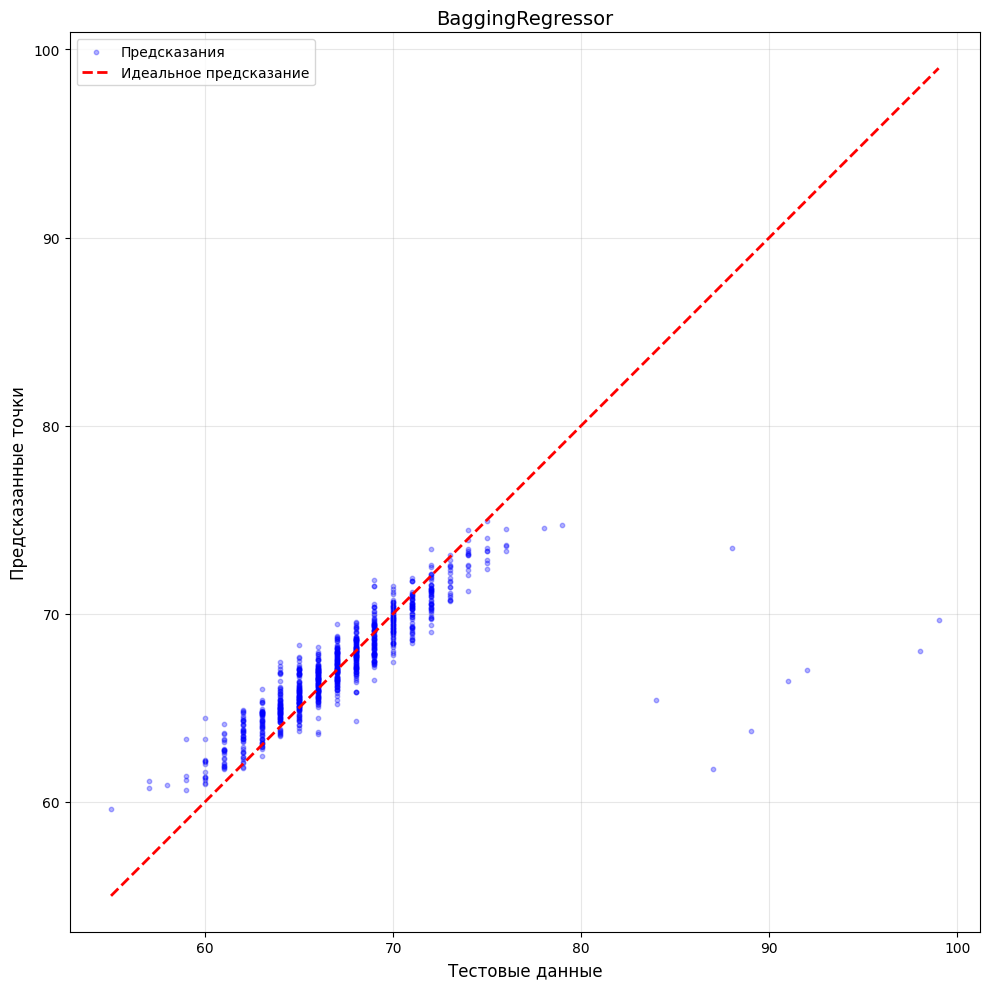

In [ ]:
best_bagging.fit(X_train, y_train)
vizual_pred_test(y_valid, best_bagging.predict(X_valid), 'BaggingRegressor')

## Случайный лес оптимизируется так же, как и обычные модели, выбирать базовую модель не надо

In [ ]:
rf = RandomForestRegressor(random_state=42, n_jobs=-1)

param_dist = {
    'n_estimators': randint(10, 150),
    'max_depth': randint(3, 50),
    'min_samples_split': randint(2, 20),
    'min_samples_leaf': randint(1, 10),
    'max_features': ['sqrt', 'log2', None],
    'bootstrap': [True, False],
    'max_samples': uniform(0.5, 0.5),
    'ccp_alpha': uniform(0, 0.05)
}

random_search = RandomizedSearchCV(
    rf,
    param_distributions=param_dist,
    n_iter=100,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    random_state=42,
    verbose=2
)

random_search.fit(X_train, y_train)

best_rf = random_search.best_estimator_

Fitting 5 folds for each of 100 candidates, totalling 500 fits


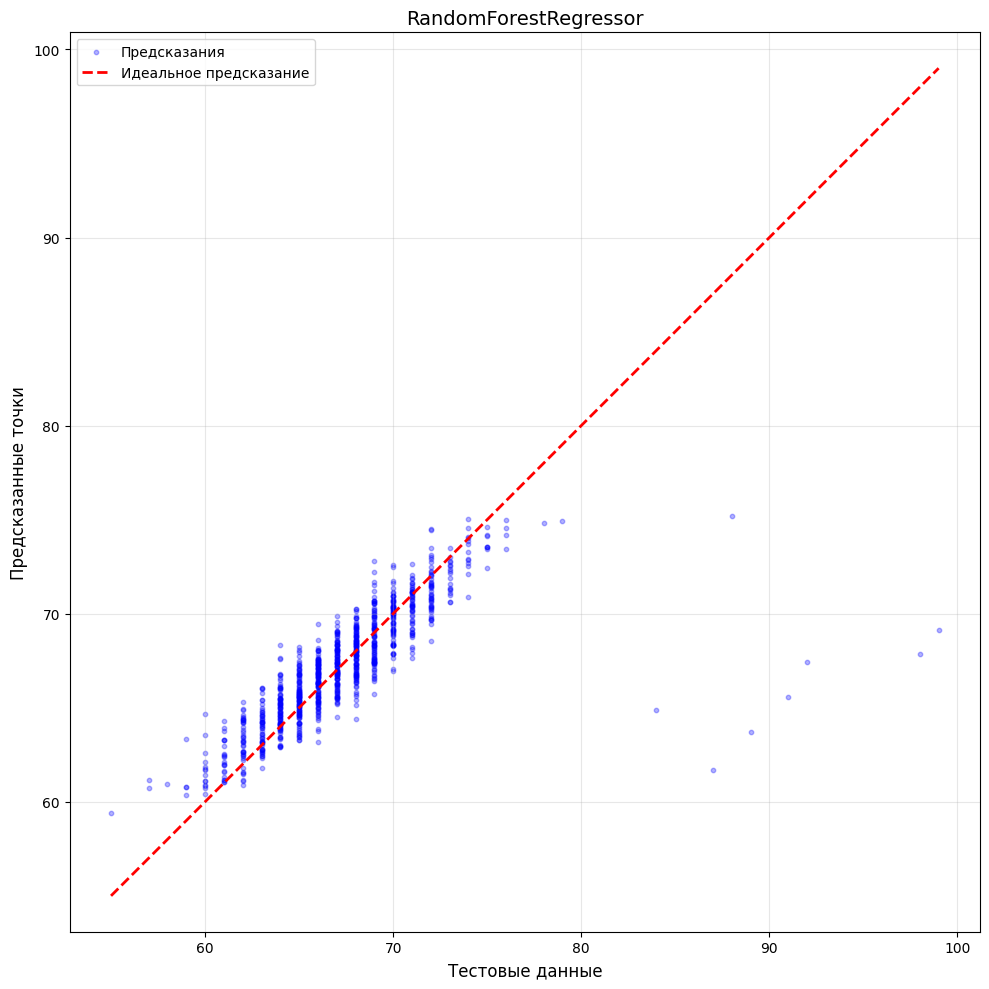

In [ ]:
best_rf.fit(X_train, y_train)
vizual_pred_test(y_valid, best_rf.predict(X_valid), 'RandomForestRegressor')

## Boosting Regressor - по аналогии с RandomForestRegressor

In [ ]:
gbr = GradientBoostingRegressor(random_state=42)

param_dist = {
    'n_estimators': randint(50, 250),
    'learning_rate': loguniform(0.01, 0.5),
    'max_depth': randint(3, 10),
    'min_samples_split': randint(2, 20),
    'min_samples_leaf': randint(1, 10),
    'max_features': ['sqrt', 'log2', None],
    'subsample': uniform(0.6, 0.4),
    'loss': ['squared_error', 'absolute_error', 'huber', 'quantile'],
    'alpha': uniform(0.1, 0.8)
}

random_search = RandomizedSearchCV(
    gbr,
    param_distributions=param_dist,
    n_iter=100,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    random_state=42,
    verbose=2
)

random_search.fit(X_train, y_train)

best_gbr = random_search.best_estimator_

Fitting 5 folds for each of 100 candidates, totalling 500 fits


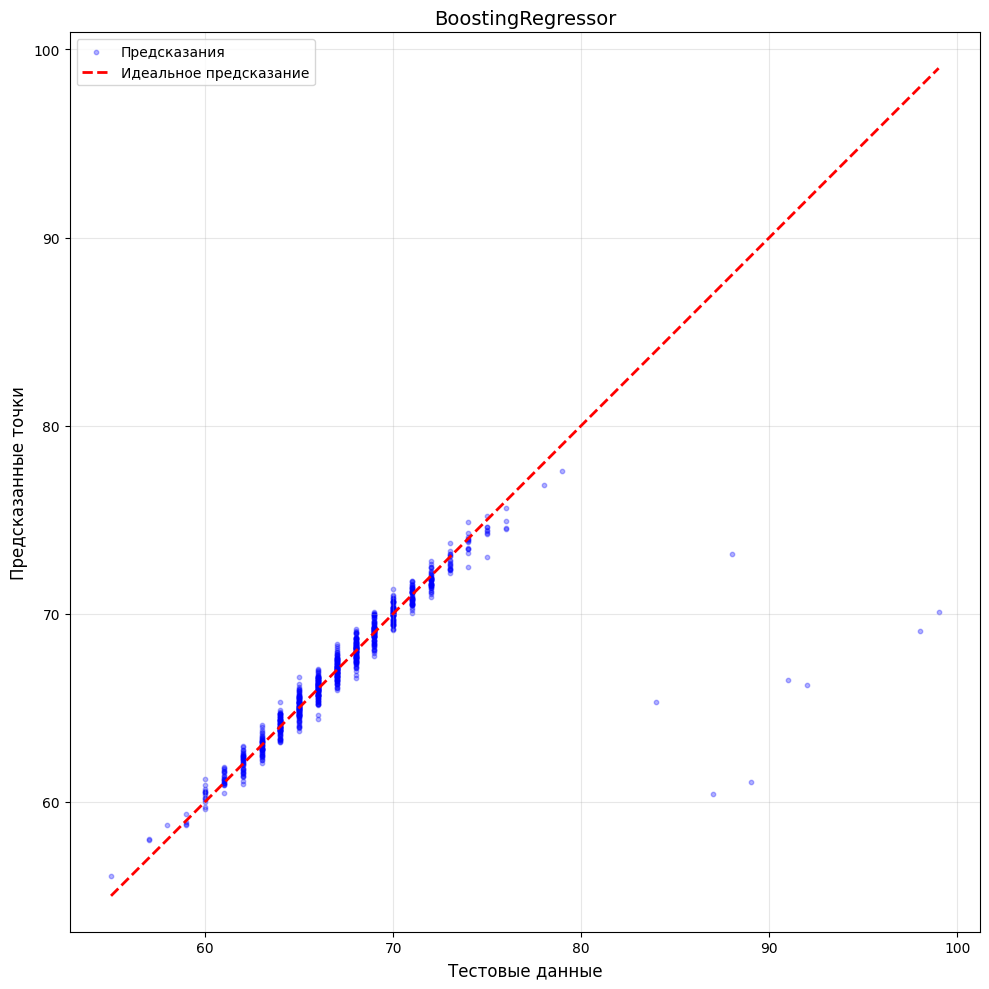

In [ ]:
best_gbr.fit(X_train, y_train)
vizual_pred_test(y_valid, best_gbr.predict(X_valid), 'BoostingRegressor')

## StackingRegressor - берем те же 6 моделей, что и для VotingRegressor, и будем пытаться выбрать для них лучшую финальную модель для предсказания (довольно долго выполняется, поэтому не буду слишком много итерировать)

In [ ]:
param_grid = {
    'final_estimator': [Ridge(), SVR(), RandomForestRegressor(random_state=42, n_jobs=-1),
                        GradientBoostingRegressor(random_state=42)]
}

stacking = StackingRegressor(
    estimators=estimators,
    cv=5,
    passthrough=False
)

grid_search = GridSearchCV(
    stacking,
    param_grid=param_grid,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=2
)

grid_search.fit(X_train, y_train)

best_stacking = grid_search.best_estimator_

Fitting 5 folds for each of 4 candidates, totalling 20 fits


Exception ignored in: <_io.BytesIO object at 0x0000028C117F67A0>
Traceback (most recent call last):
  File "c:\Program Files\Python313\Lib\dis.py", line 909, in findlinestarts
    def findlinestarts(code):
BufferError: Existing exports of data: object cannot be re-sized


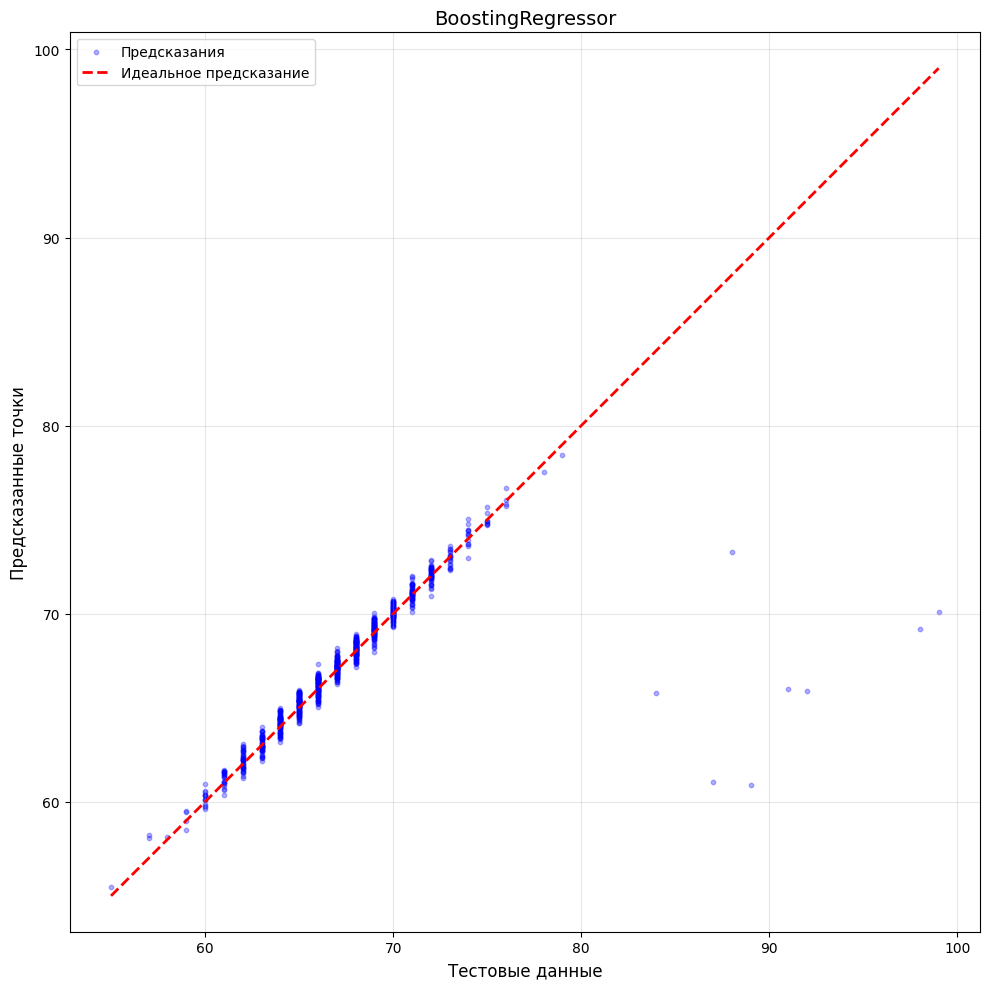

In [ ]:
best_stacking.fit(X_train, y_train)
vizual_pred_test(y_valid, best_stacking.predict(X_valid), 'BoostingRegressor')

## Давайте сохраним результат в виде csv-файла

In [ ]:
results_ensembles = pd.DataFrame(columns=['model', 'params', 'MAE', 'RMSE', 'R2'])

In [ ]:
def resulting(model, df, model_name):
    prediction = model.predict(df)
    row = {'model': model_name,
                  'params': model.get_params(),
                  'MAE': mae(y_valid, prediction),
                  'RMSE': rmse(y_valid, prediction),
                  'R2': r2(y_valid, prediction)}
    results_ensembles.loc[len(results_ensembles)] = row

In [ ]:
resulting(best_voting, X_valid, "VotingRegressor")
resulting(best_bagging, X_valid, "BaggingRegressor")
resulting(best_rf, X_valid, "RandomForestRegressor")
resulting(best_gbr, X_valid, "BoostingRegressor")
resulting(best_stacking, X_valid, "StackingRegressor")

In [ ]:
results_ensembles

,model,params,MAE,RMSE,R2
0,VotingRegressor,"{'estimators': [('svr_rbf', SVR(C=50, epsilon=...",0.628660,2.310564,0.662210
1,BaggingRegressor,"{'bootstrap': True, 'bootstrap_features': Fals...",1.145797,2.519624,0.598318
2,RandomForestRegressor,"{'bootstrap': True, 'ccp_alpha': 0.00978955673...",1.273089,2.596215,0.573527
3,BoostingRegressor,"{'alpha': 0.4507792984144696, 'ccp_alpha': 0.0...",0.599892,2.301610,0.664823
4,StackingRegressor,"{'cv': 5, 'estimators': [('svr_rbf', SVR(C=50,...",0.554674,2.284959,0.669655


In [ ]:
results_ensembles.to_csv("data/results_ensembles.csv")